In [86]:
import numpy as np
import pandas as pd

from scipy.stats import pearsonr, spearmanr, mannwhitneyu, ttest_ind, ttest_rel, wilcoxon, shapiro
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.utils import resample

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import mpl_scatter_density # needed for density scatter plots
from astropy.visualization import LogStretch
from astropy.visualization.mpl_normalize import ImageNormalize

# COLORS:
# "Viridis-like" colormap with white background
white_viridis = LinearSegmentedColormap.from_list("white_viridis", [
    (0, "#ffffff"),
    (1e-20, "#440053"),
    (0.2, "#404388"),
    (0.4, "#2a788e"),
    (0.6, "#21a784"),
    (0.8, "#78d151"),
    (1, "#fde624"),
], N=256)
# "Viridis-like" colormap with white background
white_viridis_r = LinearSegmentedColormap.from_list("white_viridis", [
    (0, "#ffffff"),
    (1e-20, "#fde624"),
    (0.4, "#78d151"),
    (0.6, "#21a784"),
    (0.7, "#2a788e"),
    (0.8, "#404388"),
    (1, "#440053"),
], N=256)
prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]

rng = np.random.RandomState(47)

In [87]:
print(
    "scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/k562_allelic_mpra_snps.csv.gz ~/github/scratch/siraj_mpra"
)
print(
    "scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/media-3_oligos_snps_cleaned_enformer_windows_holdouts.bed.gz \
        ~/github/scratch/siraj_mpra"
)
print(
    "scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/k562_mpra_snps_enformer_center.npz ~/github/scratch/siraj_mpra"
)

scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/k562_allelic_mpra_snps.csv.gz ~/github/scratch/siraj_mpra
scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/media-3_oligos_snps_cleaned_enformer_windows_holdouts.bed.gz         ~/github/scratch/siraj_mpra
scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/k562_mpra_snps_enformer_center.npz ~/github/scratch/siraj_mpra


In [88]:
data = pd.read_csv("~/github/scratch/siraj_mpra/k562_allelic_mpra_snps.csv.gz")

In [89]:
data = data[np.isfinite(data["log2fc_clipnet_holdout"])]
data = data[
    [
        "fold", "variant", "emVar_K562", "active_K562", "log2fc_expt",
        "log2fc_clipnet_ensemble", "log2fc_clipnet_holdout", "log2fc_procapnet_ensemble"
    ]
]
data = data[np.isfinite(data["log2fc_clipnet_holdout"])]
data.dropna(inplace=True)
data = data[data.active_K562 == 1]

In [90]:
enformer_pred = np.load("/Users/adamhe/github/scratch/siraj_mpra/k562_mpra_snps_enformer_center.npz")
enformer_variants = pd.read_csv(
    "/Users/adamhe/github/scratch/siraj_mpra/media-3_oligos_snps_cleaned_enformer_windows_holdouts.bed.gz",
    sep="\t",
    header=None
).iloc[:, 3]

In [91]:
enformer_log2fc = pd.DataFrame(
    np.log2(enformer_pred["ref"].mean(axis=1) / enformer_pred["alt"].mean(axis=1))
)
enformer_log2fc.columns = [f"enformer_{i}" for i in range(enformer_log2fc.shape[1])]
enformer_log2fc["variant"] = enformer_variants

In [92]:
data = data.merge(enformer_log2fc, on="variant", suffixes=("", "_enformer"))
data.shape

(6095, 17)

In [93]:
print(average_precision_score(data.emVar_K562, data.log2fc_clipnet_holdout ** 2))
print(average_precision_score(data.emVar_K562, data.log2fc_procapnet_ensemble ** 2))
print(average_precision_score(data.emVar_K562, data.enformer_4 ** 2))

0.4903219497676783
0.4430446557055073
0.4095665718627676


In [94]:
print(average_precision_score(data.emVar_K562, data.log2fc_clipnet_holdout ** 2))
print(average_precision_score(data.emVar_K562, data.log2fc_procapnet_ensemble ** 2))
print(average_precision_score(data.emVar_K562, data.enformer_4 ** 2))
for i in range(9):
    print(average_precision_score(data.emVar_K562, data[f"enformer_{i}"] ** 2))

0.4903219497676783
0.4430446557055073
0.4095665718627676
0.40182364690544503
0.4031036671045944
0.4029258446844746
0.40820762797225263
0.4095665718627676
0.4044861626624813
0.40043842028199983
0.37192103351137473
0.3650324111685055


In [118]:
procapnet_map_bootstrap = []
clipnet_map_bootstrap = []
enformer_map_bootstrap = []
random_map_bootstrap = []

for i in range(1000):
    emvar, clipnet, procapnet, enformer = resample(
        data.emVar_K562,
        data.log2fc_clipnet_holdout ** 2,
        data.log2fc_procapnet_ensemble ** 2,
        data.enformer_4 ** 2,
        random_state=rng
    )
    clipnet_map_bootstrap.append(average_precision_score(emvar, clipnet))
    procapnet_map_bootstrap.append(average_precision_score(emvar, procapnet))
    enformer_map_bootstrap.append(average_precision_score(emvar, enformer))
    random_map_bootstrap.append(average_precision_score(emvar, rng.rand(emvar.shape[0])))

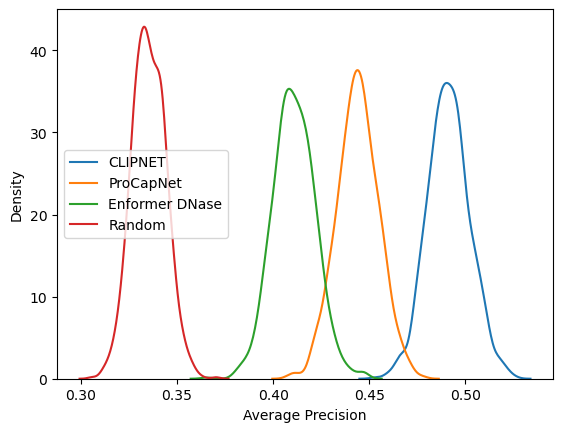

In [120]:
sns.kdeplot(clipnet_map_bootstrap, label="CLIPNET", color=colors[0])
sns.kdeplot(procapnet_map_bootstrap, label="ProCapNet", color=colors[1])
sns.kdeplot(enformer_map_bootstrap, label="Enformer DNase", color=colors[2])
sns.kdeplot(random_map_bootstrap, label="Random", color=colors[3])
plt.xlabel("Average Precision")
plt.ylabel("Density")
plt.legend()

In [97]:
#wilcoxon(procapnet_map_bootstrap, clipnet_map_bootstrap)
#wilcoxon(enformer_map_bootstrap, clipnet_map_bootstrap)
wilcoxon(procapnet_map_bootstrap, enformer_map_bootstrap)

WilcoxonResult(statistic=47.0, pvalue=3.8298730478417535e-165)

In [98]:
ttest_rel(procapnet_map_bootstrap, clipnet_map_bootstrap)

TtestResult(statistic=-182.66800097475956, pvalue=0.0, df=999)

Text(0.5, 0, 'CLIPNET - ProCapNet Average Precision')

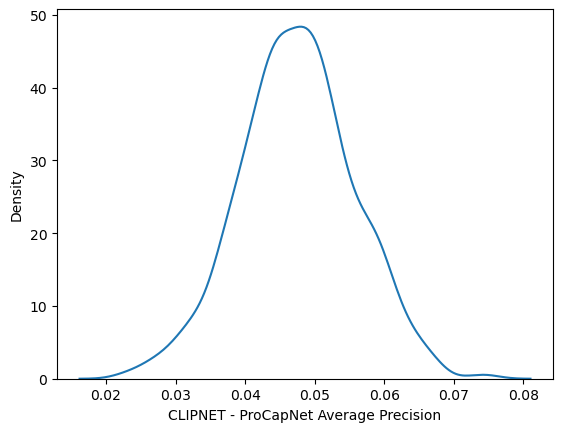

In [99]:
sns.kdeplot(np.array(clipnet_map_bootstrap) - np.array(procapnet_map_bootstrap))
plt.xlabel("CLIPNET - ProCapNet Average Precision")

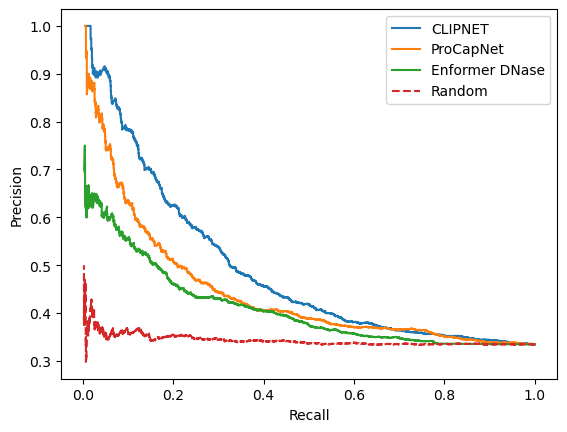

In [114]:
# Compute precision and recall
precision, recall, _ = precision_recall_curve(data.emVar_K562, data.log2fc_clipnet_ensemble ** 2)
precision2, recall2, _ = precision_recall_curve(data.emVar_K562, data.log2fc_procapnet_ensemble ** 2)
precision3, recall3, _ = precision_recall_curve(data.emVar_K562, data.enformer_4 ** 2)
#precision4, recall4, _ = precision_recall_curve(data.emVar_K562, data.enformer_8 ** 2)
rand_precision, rand_recall, _ = precision_recall_curve(data.emVar_K562, np.random.uniform(0, 1, len(data)))

trim = 10
# Plot Precision-Recall Curve
plt.plot(recall[:-trim], precision[:-trim])
plt.plot(recall2[:-trim], precision2[:-trim])
plt.plot(recall3[:-trim], precision3[:-trim])
#plt.plot(recall4[:-trim], precision4[:-trim])
plt.plot(rand_recall[:-trim], rand_precision[:-trim], linestyle='--')
plt.xlabel('Recall')
plt.ylabel('Precision')
#plt.title('Precision-Recall Curve')
plt.legend(["CLIPNET", "ProCapNet", "Enformer DNase", "Random"])
plt.show()

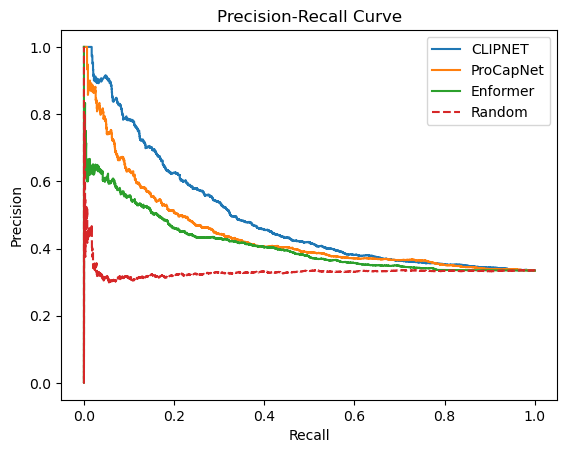

In [101]:
# Compute precision and recall
precision, recall, _ = precision_recall_curve(data.emVar_K562, data.log2fc_clipnet_ensemble ** 2)
precision2, recall2, _ = precision_recall_curve(data.emVar_K562, data.log2fc_procapnet_ensemble ** 2)
precision3, recall3, _ = precision_recall_curve(data.emVar_K562, data.enformer_4 ** 2)
rand_precision, rand_recall, _ = precision_recall_curve(data.emVar_K562, np.random.uniform(0, 1, len(data)))

# Plot Precision-Recall Curve
plt.plot(recall, precision)
plt.plot(recall2, precision2)
plt.plot(recall3, precision3)
plt.plot(rand_recall, rand_precision, linestyle='--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(["CLIPNET", "ProCapNet", "Enformer", "Random"])
plt.show()

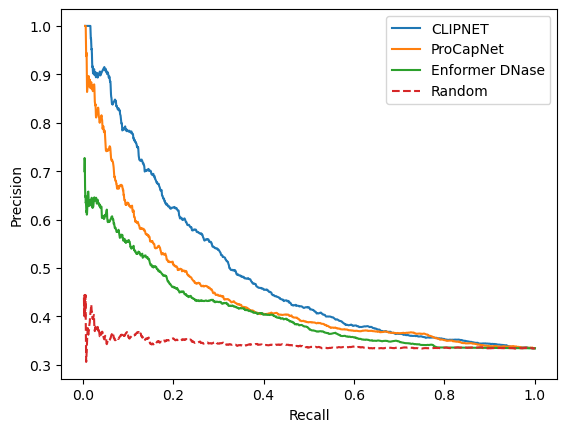

In [117]:
trim = 10
# Plot Precision-Recall Curve
sns.lineplot(x=recall[:-trim], y=precision[:-trim], errorbar=None)
sns.lineplot(x=recall2[:-trim], y=precision2[:-trim], errorbar=None)
sns.lineplot(x=recall3[:-trim], y=precision3[:-trim], errorbar=None)
sns.lineplot(x=rand_recall[:-trim], y=rand_precision[:-trim], linestyle='--', errorbar=None)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(["CLIPNET", "ProCapNet", "Enformer DNase", "Random"])
#plt.show()


In [45]:
precision[-1:]

array([1.])

In [48]:
recall[-1:]

array([0.])

In [119]:
data = pd.read_csv("~/github/scratch/k562_allelic_mpra_snps.csv.gz")
data = data[np.isfinite(data["log2fc_clipnet_holdout"])]
data = data[
    [
        "fold", "variant", "emVar_K562", "active_K562", "log2fc_expt",
        "log2fc_clipnet_ensemble", "log2fc_clipnet_holdout", "log2fc_procapnet_ensemble"
    ]
]
data = data[np.isfinite(data["log2fc_clipnet_holdout"])]
data.dropna(inplace=True)

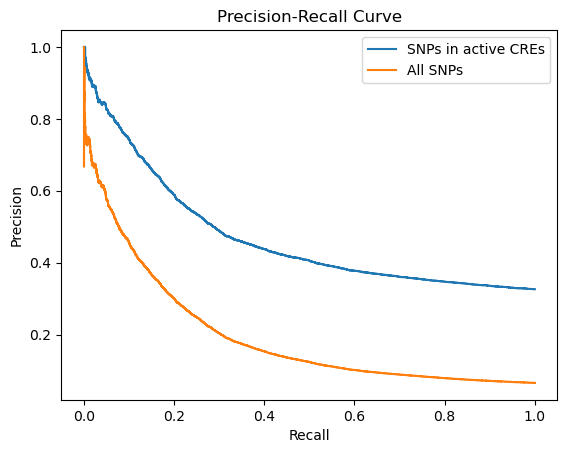

In [127]:
# Compute precision and recall
precision, recall, _ = precision_recall_curve(
    data[data.active_K562 == 1].emVar_K562, data[data.active_K562 == 1].log2fc_clipnet_ensemble ** 2
)
precision2, recall2, _ = precision_recall_curve(data.emVar_K562, data.log2fc_clipnet_ensemble ** 2)

# Plot Precision-Recall Curve
plt.plot(recall, precision)
plt.plot(recall2, precision2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(["SNPs in active CREs", "All SNPs"])
plt.show()


In [116]:
data[data.active_K562 == 1].emVar_K562, data[data.active_K562 == 1].log2fc_clipnet_ensemble ** 2

(6         1.0
 7         0.0
 8         0.0
 28        0.0
 29        1.0
          ... 
 281306    0.0
 281307    0.0
 281315    0.0
 281317    0.0
 281323    1.0
 Name: emVar_K562, Length: 50543, dtype: float64,
 6         0.000245
 7         0.004513
 8         0.000005
 28        0.001592
 29        0.014026
             ...   
 281306    0.001981
 281307    0.000172
 281315    0.000050
 281317    0.003593
 281323    0.015124
 Name: log2fc_clipnet_ensemble, Length: 50543, dtype: float64)

In [117]:
data.emVar_K562, data.log2fc_clipnet_ensemble ** 2

(6         1.0
 7         0.0
 8         0.0
 28        0.0
 29        1.0
          ... 
 281306    0.0
 281307    0.0
 281315    0.0
 281317    0.0
 281323    1.0
 Name: emVar_K562, Length: 50543, dtype: float64,
 6         0.000245
 7         0.004513
 8         0.000005
 28        0.001592
 29        0.014026
             ...   
 281306    0.001981
 281307    0.000172
 281315    0.000050
 281317    0.003593
 281323    0.015124
 Name: log2fc_clipnet_ensemble, Length: 50543, dtype: float64)

In [124]:
data.shape[0]

(252040, 8)

In [185]:
sns.__version__

'0.11.0'